In [ ]:
!pip install ultralytics httpx --quiet

import torch
print("=" * 40)
print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))
else:
    print("WARNING : No GPU detected!")
    print("Go to Runtime → Change runtime type → T4 GPU")
print("=" * 40)


PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4


In [ ]:
import cv2
import numpy as np
import math
import os

OUTPUT_PATH = "/content/test_video.mp4"
WIDTH, HEIGHT = 640, 480
FPS     = 30
SECONDS = 30

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_PATH, fourcc, FPS, (WIDTH, HEIGHT))

def draw_face(frame, cx, cy, size, eyes_open=True):
    # Skin-toned head ellipse
    cv2.ellipse(frame, (cx, cy), (size, int(size * 1.25)),
                0, 0, 360, (160, 120, 90), -1)
    cv2.ellipse(frame, (cx, cy), (size, int(size * 1.25)),
                0, 0, 360, (130, 95, 70), 2)
    ex = size // 3
    ey = size // 6
    if eyes_open:
        for sx in (-1, 1):
            ex_pos = cx + sx * ex
            # White of eye
            cv2.ellipse(frame, (ex_pos, cy - ey),
                        (size // 6, size // 9), 0, 0, 360, (240, 235, 225), -1)
            # Iris
            cv2.circle(frame, (ex_pos, cy - ey), size // 12, (60, 100, 140), -1)
            # Pupil
            cv2.circle(frame, (ex_pos, cy - ey), size // 20, (20, 20, 20), -1)
    else:
        for sx in (-1, 1):
            ex_pos = cx + sx * ex
            cv2.line(frame,
                     (ex_pos - size // 8, cy - ey),
                     (ex_pos + size // 8, cy - ey),
                     (80, 55, 40), 4)
    # Nose
    cv2.line(frame, (cx, cy - ey + 10), (cx - 6, cy + 10), (130, 95, 70), 2)
    cv2.line(frame, (cx, cy - ey + 10), (cx + 6, cy + 10), (130, 95, 70), 2)
    # Mouth
    cv2.ellipse(frame, (cx, cy + size // 3),
                (size // 5, size // 10), 0, 0, 180, (110, 70, 70), 2)

def draw_phone(frame, x, y):
    # Phone body
    cv2.rectangle(frame, (x, y), (x + 55, y + 95), (25, 25, 30), -1)
    cv2.rectangle(frame, (x + 3, y + 8), (x + 52, y + 87), (70, 140, 190), -1)
    cv2.rectangle(frame, (x, y), (x + 55, y + 95), (15, 15, 20), 2)
    # Screen text lines
    cv2.line(frame, (x + 10, y + 25), (x + 45, y + 25), (255, 255, 255), 1)
    cv2.line(frame, (x + 10, y + 35), (x + 38, y + 35), (255, 255, 255), 1)
    cv2.line(frame, (x + 10, y + 45), (x + 42, y + 45), (200, 200, 200), 1)

def draw_background(frame, t):
    # Dark car interior background
    frame[:] = (55, 65, 75)
    # Windshield area (top portion — lighter)
    cv2.rectangle(frame, (60, 0), (WIDTH - 60, HEIGHT // 2 - 40),
                  (90, 105, 115), -1)
    # Road vanishing point
    road_y = HEIGHT // 2 - 30
    cv2.line(frame, (WIDTH // 2, road_y), (0, HEIGHT), (70, 80, 88), 3)
    cv2.line(frame, (WIDTH // 2, road_y), (WIDTH, HEIGHT), (70, 80, 88), 3)
    # Dashboard panel
    cv2.rectangle(frame, (0, HEIGHT - 90), (WIDTH, HEIGHT), (40, 44, 50), -1)
    # Steering wheel (bottom center)
    cv2.ellipse(frame, (WIDTH // 2, HEIGHT + 30),
                (150, 150), 0, 200, 340, (55, 58, 65), 14)
    cv2.line(frame, (WIDTH // 2, HEIGHT - 60),
             (WIDTH // 2, HEIGHT + 30), (55, 58, 65), 8)
    # Moving road dashes (animated)
    dash_offset = int(t * 120) % 80
    for dy in range(dash_offset, HEIGHT, 80):
        cv2.rectangle(frame,
                      (WIDTH // 2 - 4, road_y + dy),
                      (WIDTH // 2 + 4, road_y + dy + 40),
                      (200, 195, 160), -1)

def draw_arm(frame, fx, fy, px, py, size):
    # Draw arm from face toward phone
    cv2.line(frame,
             (fx + size, fy + size),
             (px + 27, py + 47),
             (150, 110, 80), 18)

def draw_hud(frame, scenario_name, color, t, WIDTH, HEIGHT):
    # Top HUD bar
    overlay = frame.copy()
    cv2.rectangle(overlay, (0, 0), (WIDTH, 36), (20, 20, 25), -1)
    cv2.addWeighted(overlay, 0.75, frame, 0.25, 0, frame)
    cv2.putText(frame, scenario_name,
                (10, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 2)
    # Timestamp
    mm, ss = int(t) // 60, int(t) % 60
    cv2.putText(frame, f"{mm:02d}:{ss:02d}",
                (WIDTH - 70, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (180, 180, 180), 1)
    # Bottom label strip
    cv2.rectangle(frame, (0, HEIGHT - 28), (WIDTH, HEIGHT), (20, 20, 25), -1)
    cv2.putText(frame, "DMS/OMS Test Video  |  Synthetic Scenario",
                (10, HEIGHT - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (130, 130, 130), 1)
    # Progress bar
    prog = int((t / 30.0) * WIDTH)
    cv2.rectangle(frame, (0, HEIGHT - 4), (prog, HEIGHT), color, -1)

print("Generating 30s synthetic driver video...")
print("Scenarios:")
print("  0-6s   → Normal (attentive driving)")
print("  6-12s  → Drowsiness (eyes closing)")
print("  12-18s → Phone use (distracted)")
print("  18-24s → Looking away (head turned)")
print("  24-30s → Recovery (back to normal)")
print()

TOTAL_FRAMES = FPS * SECONDS

for i in range(TOTAL_FRAMES):
    frame = np.zeros((HEIGHT, WIDTH, 3), dtype=np.uint8)
    t = i / FPS
    seg = int(t / 6)

    draw_background(frame, t)

    # ── Segment 0: Normal attentive (0-6s) ──────────────────────
    if seg == 0:
        cx, cy = WIDTH // 2, HEIGHT // 3 - 10
        draw_face(frame, cx, cy, 68, eyes_open=True)
        label, color = "NORMAL — Attentive driver", (60, 200, 60)

    # ── Segment 1: Drowsiness (6-12s) ───────────────────────────
    elif seg == 1:
        local_t = t - 6
        # Eyes close and open on a slow sinusoidal cycle
        blink = math.sin(local_t * 0.9 - 0.5)
        eyes_open = blink > -0.3
        # Head droops forward slightly
        head_droop = int(18 * max(0, -blink))
        cx = WIDTH // 2
        cy = HEIGHT // 3 - 10 + head_droop
        draw_face(frame, cx, cy, 68, eyes_open=eyes_open)
        label, color = "DROWSY — Eyes closing / head drooping", (0, 140, 255)

    # ── Segment 2: Phone use (12-18s) ───────────────────────────
    elif seg == 2:
        # Face shifts slightly left and down (looking at phone)
        cx = WIDTH // 2 - 25
        cy = HEIGHT // 3 + 10
        draw_face(frame, cx, cy, 68, eyes_open=True)
        # Phone in right hand area
        px = WIDTH // 2 + 40
        py = HEIGHT // 3 + 10
        draw_arm(frame, cx, cy, px, py, 68)
        draw_phone(frame, px, py)
        label, color = "PHONE USE — Device in hand / face turned", (0, 60, 255)

    # ── Segment 3: Looking away (18-24s) ────────────────────────
    elif seg == 3:
        local_t = t - 18
        # Face slides off to the side
        slide = int(90 * abs(math.sin(local_t * 0.55)))
        cx = WIDTH // 2 + slide
        cy = HEIGHT // 3 - 10
        if cx < WIDTH - 60:
            draw_face(frame, cx, cy, 68, eyes_open=True)
        # else: face out of frame — nothing to draw
        label, color = "LOOKING AWAY — Driver not facing road", (0, 60, 220)

    # ── Segment 4: Recovery / normal (24-30s) ───────────────────
    else:
        cx, cy = WIDTH // 2, HEIGHT // 3 - 10
        draw_face(frame, cx, cy, 68, eyes_open=True)
        label, color = "RECOVERY — Driver re-engaged", (60, 200, 60)

    draw_hud(frame, label, color, t, WIDTH, HEIGHT)
    writer.write(frame)

writer.release()

size_mb = os.path.getsize(OUTPUT_PATH) / 1e6
print(f"Video saved: {OUTPUT_PATH}")
print(f"Size       : {size_mb:.1f} MB")
print(f"Duration   : {SECONDS}s at {FPS} FPS ({TOTAL_FRAMES} frames)")
print()
print("Ready! Set VIDEO_PATH = '/content/test_video.mp4' in Cell 3.")

Generating 30s synthetic driver video...
Scenarios:
  0-6s   → Normal (attentive driving)
  6-12s  → Drowsiness (eyes closing)
  12-18s → Phone use (distracted)
  18-24s → Looking away (head turned)
  24-30s → Recovery (back to normal)

Video saved: /content/test_video.mp4
Size       : 2.0 MB
Duration   : 30s at 30 FPS (900 frames)

Ready! Set VIDEO_PATH = '/content/test_video.mp4' in Cell 3.


In [ ]:
from IPython.display import Video
Video(OUTPUT_PATH, embed=True, width=640, height=480)

In [ ]:
import torch

# ── Video ──────────────────────────────────────────────────────
VIDEO_PATH = "/content/test_video.mp4"   # generated by Cell 2

# ── YOLO ───────────────────────────────────────────────────────
YOLO_MODEL    = "yolov8n.pt"             # auto-downloads on first run
DEVICE        = "cuda:0" if torch.cuda.is_available() else "cpu"
YOLO_CONF     = 0.35                     # lower = catches more objects
INFER_EVERY_N = 3                        # run YOLO on every 3rd frame
MAX_FRAMES    = 80                       # stop after 80 inferences

# ── NVIDIA NIM (optional) ──────────────────────────────────────
# Leave as-is to run rules-only (no API key needed).
# Get a FREE key at https://build.nvidia.com/ to enable LLaVA.
NIM_API_KEY  = "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"
NIM_BASE_URL = "https://integrate.api.nvidia.com/v1"
NIM_MODEL    = "llava-v1.6-mistral-7b"
ENABLE_NIM   = not NIM_API_KEY.startswith("nvapi-PASTE")

print("=" * 42)
print(f"Device     : {DEVICE}")
print(f"YOLO model : {YOLO_MODEL}")
print(f"Video      : {VIDEO_PATH}")
print(f"NIM        : {'ENABLED' if ENABLE_NIM else 'DISABLED (rules-only mode)'}")
if not ENABLE_NIM:
    print("  → Get a free key at https://build.nvidia.com/")
    print("  → Paste it into NIM_API_KEY above and re-run")
print("=" * 42)


Device     : cuda:0
YOLO model : yolov8n.pt
Video      : /content/test_video.mp4
NIM        : ENABLED


In [ ]:
# Defines: Detection, YOLODetector, ROI, ROIExtractor,
#          NIMResult, NIMClient, AlertLevel, Alert, DecisionEngine

import cv2, base64, json, re, time, math
import numpy as np
from dataclasses import dataclass, field
from enum import IntEnum
from collections import deque


# ── Detection ─────────────────────────────────────────────────
@dataclass
class Detection:
    label:      str
    class_id:   int
    confidence: float
    bbox_xyxy:  tuple
    bbox_xywh:  tuple

    @property
    def area(self):
        x1, y1, x2, y2 = self.bbox_xyxy
        return max(0, x2 - x1) * max(0, y2 - y1)

    @property
    def center(self):
        x1, y1, x2, y2 = self.bbox_xyxy
        return ((x1 + x2) // 2, (y1 + y2) // 2)


# ── YOLO Detector ─────────────────────────────────────────────
class YOLODetector:
    # COCO class IDs → DMS labels
    COCO_REMAP = {0: "driver", 67: "phone"}

    def __init__(self, model_path="yolov8n.pt", device="cuda:0",
                 conf=0.35, iou=0.50):
        from ultralytics import YOLO
        self.model  = YOLO(model_path)
        self.model.to(device)
        self.conf   = conf
        self.iou    = iou
        self.device = device
        print(f"YOLOv8 loaded on {device}")

    def detect(self, frame):
        results = self.model.predict(
            source=frame, conf=self.conf, iou=self.iou,
            device=self.device, verbose=False, stream=False)
        dets = []
        for r in results:
            if r.boxes is None:
                continue
            for box in r.boxes:
                cls_id = int(box.cls[0])
                label  = self.COCO_REMAP.get(
                    cls_id, r.names.get(cls_id, f"obj_{cls_id}"))
                x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
                dets.append(Detection(
                    label      = label,
                    class_id   = cls_id,
                    confidence = float(box.conf[0]),
                    bbox_xyxy  = (x1, y1, x2, y2),
                    bbox_xywh  = tuple(box.xywhn[0].tolist()),
                ))
        return sorted(dets, key=lambda d: d.confidence, reverse=True)


# ── ROI Extractor ─────────────────────────────────────────────
LABEL_PRIORITY = {
    "face": 0, "left_eye": 1, "right_eye": 1,
    "phone": 2, "driver": 3, "person": 3, "passenger": 4,
}

@dataclass
class ROI:
    detection:   Detection
    crop:        np.ndarray
    base64_jpeg: str

    @property
    def label(self):
        return self.detection.label


class ROIExtractor:
    def __init__(self, target_size=(336, 336),
                 padding=0.18, quality=78, max_rois=2):
        self.target_size = target_size
        self.padding     = padding
        self.quality     = quality
        self.max_rois    = max_rois

    def extract(self, frame, detections):
        if not detections:
            return []
        h, w = frame.shape[:2]
        sorted_dets = sorted(
            detections,
            key=lambda d: (LABEL_PRIORITY.get(d.label, 99), -d.confidence))
        rois = []
        for det in sorted_dets[:self.max_rois]:
            x1, y1, x2, y2 = det.bbox_xyxy
            bw, bh = x2 - x1, y2 - y1
            if bw <= 0 or bh <= 0:
                continue
            px, py = int(bw * self.padding), int(bh * self.padding)
            cx1, cy1 = max(0, x1 - px), max(0, y1 - py)
            cx2, cy2 = min(w, x2 + px), min(h, y2 + py)
            crop = frame[cy1:cy2, cx1:cx2]
            if crop.size == 0:
                continue
            resized = cv2.resize(
                crop, self.target_size, interpolation=cv2.INTER_LANCZOS4)
            ok, buf = cv2.imencode(
                ".jpg", resized, [cv2.IMWRITE_JPEG_QUALITY, self.quality])
            if not ok:
                continue
            b64 = base64.b64encode(buf.tobytes()).decode("utf-8")
            rois.append(ROI(detection=det, crop=resized, base64_jpeg=b64))
        return rois


# ── NIM Client ────────────────────────────────────────────────
SYSTEM_PROMPT = (
    "You are a vehicle safety monitoring AI. "
    "Analyze driver-facing camera images. "
    "Only report what you directly observe. "
    "Respond with valid JSON only — no other text."
)

def build_nim_prompt(detections):
    lines = [
        f"  - {d.label}: conf={d.confidence:.2f}, bbox={list(d.bbox_xyxy)}"
        for d in detections[:6]
    ]
    det_str = "\n".join(lines) if lines else "  (none detected)"
    return (
        f"YOLO detections (treat as ground truth):\n{det_str}\n\n"
        "Return ONLY this JSON schema:\n"
        '{"distracted":bool,"drowsy":bool,"phone_use":bool,'
        '"looking_away":bool,"occupant_present":bool,'
        '"child_detected":bool,"confidence":float,"reason":"string"}'
    )


@dataclass
class NIMResult:
    distracted:       bool  = False
    drowsy:           bool  = False
    phone_use:        bool  = False
    looking_away:     bool  = False
    occupant_present: bool  = False
    child_detected:   bool  = False
    confidence:       float = 0.0
    reason:           str   = ""
    parse_error:      bool  = False


class NIMClient:
    def __init__(self, base_url, api_key, model, timeout=14.0):
        import httpx
        self.base_url = base_url.rstrip("/")
        self.model    = model
        self.http     = httpx.Client(
            headers={
                "Authorization": f"Bearer {api_key}",
                "Content-Type":  "application/json",
            },
            timeout=timeout,
        )

    def reason(self, rois, detections):
        if not rois:
            return NIMResult(reason="No ROI available")
        roi = rois[0]
        payload = {
            "model": self.model,
            "messages": [
                {"role": "system", "content": SYSTEM_PROMPT},
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "image_url",
                            "image_url": {
                                "url":    f"data:image/jpeg;base64,{roi.base64_jpeg}",
                                "detail": "low",   # 85 tokens → fast
                            },
                        },
                        {"type": "text", "text": build_nim_prompt(detections)},
                    ],
                },
            ],
            "max_tokens":  256,
            "temperature": 0.1,
        }
        try:
            resp = self.http.post(
                f"{self.base_url}/v1/chat/completions", json=payload)
            resp.raise_for_status()
            raw = resp.json()["choices"][0]["message"]["content"]
            return self._parse(raw)
        except Exception as e:
            return NIMResult(reason=str(e)[:80], parse_error=True)

    def _parse(self, raw):
        text = re.sub(r"^```(?:json)?\s*", "", raw.strip())
        text = re.sub(r"\s*```$", "", text).strip()
        m = re.search(r"\{.*\}", text, re.DOTALL)
        if m:
            text = m.group(0)
        try:
            d = json.loads(text)
            return NIMResult(
                distracted       = bool(d.get("distracted",       False)),
                drowsy           = bool(d.get("drowsy",           False)),
                phone_use        = bool(d.get("phone_use",        False)),
                looking_away     = bool(d.get("looking_away",     False)),
                occupant_present = bool(d.get("occupant_present", False)),
                child_detected   = bool(d.get("child_detected",   False)),
                confidence       = float(d.get("confidence", 0.0)),
                reason           = str(d.get("reason", ""))[:150],
            )
        except json.JSONDecodeError:
            return NIMResult(reason="JSON parse error", parse_error=True)


# ── Decision Engine ───────────────────────────────────────────
class AlertLevel(IntEnum):
    NONE     = 0
    LOW      = 1
    MEDIUM   = 2
    HIGH     = 3
    CRITICAL = 4


@dataclass
class Alert:
    level:      AlertLevel
    code:       str
    message:    str
    confidence: float
    source:     str

    def is_actionable(self):
        return self.level >= AlertLevel.MEDIUM


class DecisionEngine:
    def __init__(self, drowsy_sec=2.0, phone_sec=1.5, away_sec=2.5):
        self.drowsy_sec        = drowsy_sec
        self.phone_sec         = phone_sec
        self.away_sec          = away_sec
        self.eyes_closed_since = None
        self.phone_since       = None
        self.away_since        = None
        self.nim_history       = deque(maxlen=5)
        self.last_nim          = None

    def update_nim(self, result):
        if result and not result.parse_error:
            self.last_nim = result
            self.nim_history.append(result)

    def evaluate(self, detections):
        now = time.time()
        labels    = {d.label for d in detections}
        hi_conf   = {d.label for d in detections if d.confidence > 0.50}

        face_visible = bool({"driver", "person", "face"} & labels)
        eyes_visible = bool({"left_eye", "right_eye"} & labels)

        # ── Rule 1: drowsiness ────────────────────────────────
        if face_visible and not eyes_visible:
            if self.eyes_closed_since is None:
                self.eyes_closed_since = now
            dur = now - self.eyes_closed_since
            if dur >= self.drowsy_sec:
                lvl = AlertLevel.CRITICAL if dur > 4.0 else AlertLevel.HIGH
                return Alert(lvl, "DROWSY",
                             f"Eyes closed {dur:.1f}s — drowsiness",
                             0.85, "rule")
        else:
            self.eyes_closed_since = None

        # ── Rule 2: phone ─────────────────────────────────────
        phone_seen = bool({"phone", "cell phone"} & hi_conf)
        if phone_seen:
            if self.phone_since is None:
                self.phone_since = now
            dur = now - self.phone_since
            if dur >= self.phone_sec:
                return Alert(AlertLevel.HIGH, "PHONE_USE",
                             f"Phone detected {dur:.1f}s",
                             0.90, "rule")
        else:
            self.phone_since = None

        # ── Rule 3: looking away ──────────────────────────────
        if not face_visible:
            if self.away_since is None:
                self.away_since = now
            dur = now - self.away_since
            if dur >= self.away_sec:
                return Alert(AlertLevel.MEDIUM, "LOOKING_AWAY",
                             f"Driver not visible {dur:.1f}s",
                             0.75, "rule")
        else:
            self.away_since = None

        # ── NIM semantic layer ────────────────────────────────
        if self.nim_history:
            n   = len(self.nim_history)
            nim = self.last_nim
            drz = sum(1 for r in self.nim_history if r.drowsy)     / n
            phz = sum(1 for r in self.nim_history if r.phone_use)  / n
            dis = sum(1 for r in self.nim_history if r.distracted) / n
            if drz > 0.5 and nim.confidence > 0.60:
                return Alert(AlertLevel.HIGH,   "NIM_DROWSY",
                             nim.reason, nim.confidence, "nim")
            if phz > 0.5 and nim.confidence > 0.65:
                return Alert(AlertLevel.HIGH,   "NIM_PHONE",
                             nim.reason, nim.confidence, "nim")
            if dis > 0.5 and nim.confidence > 0.55:
                return Alert(AlertLevel.MEDIUM, "NIM_DISTRACTED",
                             nim.reason, nim.confidence, "nim")

        return Alert(AlertLevel.NONE, "ALL_CLEAR",
                     "Driver attentive", 1.0, "rule")


print("All modules loaded!")
print("  YOLODetector  — ready")
print("  ROIExtractor  — ready")
print("  NIMClient     — ready")
print("  DecisionEngine — ready")


All modules loaded!
  YOLODetector  — ready
  ROIExtractor  — ready
  NIMClient     — ready
  DecisionEngine — ready


In [ ]:
detector  = YOLODetector(model_path=YOLO_MODEL, device=DEVICE, conf=YOLO_CONF)
extractor = ROIExtractor(target_size=(336, 336), padding=0.18, max_rois=2)
engine    = DecisionEngine(drowsy_sec=2.0, phone_sec=1.5, away_sec=2.5)

nim_client = None
if ENABLE_NIM:
    nim_client = NIMClient(NIM_BASE_URL, NIM_API_KEY, NIM_MODEL)
    print("NIM client initialized — NVIDIA cloud API")
else:
    print("NIM disabled — running in rules-only mode")

print("All components ready!")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 loaded on cuda:0
NIM client initialized — NVIDIA cloud API
All components ready!


In [ ]:
import cv2
from google.colab.patches import cv2_imshow

LEVEL_COLORS = {
    AlertLevel.NONE:     (50,  200,  50),
    AlertLevel.LOW:      (50,  200,  50),
    AlertLevel.MEDIUM:   (0,   165, 255),
    AlertLevel.HIGH:     (0,    60, 255),
    AlertLevel.CRITICAL: (0,     0, 180),
}

def draw_overlay(frame, detections, alert, nim_result):
    out = frame.copy()
    h, w = out.shape[:2]

    # Bounding boxes + labels
    for det in detections:
        x1, y1, x2, y2 = det.bbox_xyxy
        if det.label in ("driver", "person"):
            c = (50, 210, 50)
        elif det.label == "phone":
            c = (0, 60, 255)
        else:
            c = (255, 165, 0)
        cv2.rectangle(out, (x1, y1), (x2, y2), c, 2)
        label_txt = f"{det.label} {det.confidence:.2f}"
        cv2.rectangle(out, (x1, max(y1 - 22, 0)),
                      (x1 + len(label_txt) * 9, max(y1, 22)), c, -1)
        cv2.putText(out, label_txt,
                    (x1 + 2, max(y1 - 5, 16)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.52, (255, 255, 255), 1)

    # Alert banner (top)
    bc = LEVEL_COLORS.get(alert.level, (100, 100, 100))
    cv2.rectangle(out, (0, 0), (w, 40), bc, -1)
    alert_txt = f"[{alert.level.name}]  {alert.code}  —  {alert.message}  (src:{alert.source})"
    cv2.putText(out, alert_txt,
                (8, 26), cv2.FONT_HERSHEY_SIMPLEX, 0.60, (255, 255, 255), 2)

    # NIM info bar (bottom)
    if nim_result and not nim_result.parse_error:
        nim_txt = (
            f"NIM: conf={nim_result.confidence:.2f}  "
            f"drowsy={nim_result.drowsy}  "
            f"phone={nim_result.phone_use}  "
            f"distracted={nim_result.distracted}  "
            f"| {nim_result.reason[:55]}"
        )
        bar_color = (30, 30, 35)
    else:
        nim_txt   = "NIM: disabled — running rules-only mode"
        bar_color = (30, 30, 35)

    cv2.rectangle(out, (0, h - 30), (w, h), bar_color, -1)
    cv2.putText(out, nim_txt,
                (8, h - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (190, 190, 190), 1)
    return out

print("draw_overlay() helper ready")

draw_overlay() helper ready


Video : 900 frames @ 30.0 FPS
Config: YOLO every 3 frames, max 80 inferences

 Frame      YOLO       NIM  Detections                  Alert
────────────────────────────────────────────────────────────────────────────
     3  2048.0ms     0.0ms  []                          [NONE] ALL_CLEAR
     6    47.2ms     0.0ms  []                          [NONE] ALL_CLEAR
     9    11.9ms     0.0ms  []                          [NONE] ALL_CLEAR
    12    26.5ms     0.0ms  []                          [NONE] ALL_CLEAR
    15    24.4ms     0.0ms  []                          [NONE] ALL_CLEAR
    18    19.9ms     0.0ms  []                          [NONE] ALL_CLEAR
    21    21.8ms     0.0ms  []                          [NONE] ALL_CLEAR
    24    12.7ms     0.0ms  []                          [NONE] ALL_CLEAR

── Frame 24 annotated ──────────────────────────


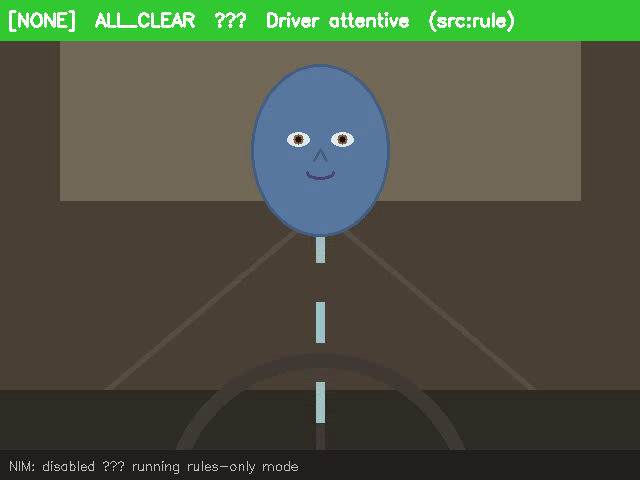

────────────────────────────────────────────────────

    27    23.5ms     0.0ms  []                          [NONE] ALL_CLEAR
    30   157.4ms    72.1ms  ['stop sign']               [NONE] ALL_CLEAR
    33    15.1ms     0.0ms  []                          [NONE] ALL_CLEAR
    36    30.3ms     0.0ms  []                          [NONE] ALL_CLEAR
    39    28.2ms     0.0ms  []                          [NONE] ALL_CLEAR
    42    30.2ms     0.0ms  []                          [NONE] ALL_CLEAR
    45    26.3ms     0.0ms  []                          [NONE] ALL_CLEAR
    48    10.7ms     0.0ms  []                          [NONE] ALL_CLEAR

── Frame 48 annotated ──────────────────────────


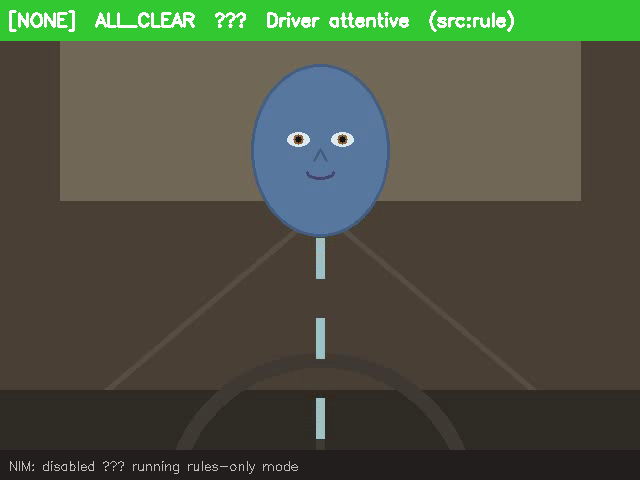

────────────────────────────────────────────────────

    51    32.9ms    16.8ms  ['stop sign']               [NONE] ALL_CLEAR
    54    18.5ms     0.0ms  []                          [NONE] ALL_CLEAR
    57    24.1ms     0.0ms  []                          [NONE] ALL_CLEAR
    60    27.1ms     0.0ms  []                          [NONE] ALL_CLEAR
    63    27.3ms     0.0ms  []                          [NONE] ALL_CLEAR
    66    17.2ms     0.0ms  []                          [NONE] ALL_CLEAR
    69    29.7ms     0.0ms  []                          [NONE] ALL_CLEAR
    72    15.4ms     0.0ms  []                          [NONE] ALL_CLEAR

── Frame 72 annotated ──────────────────────────


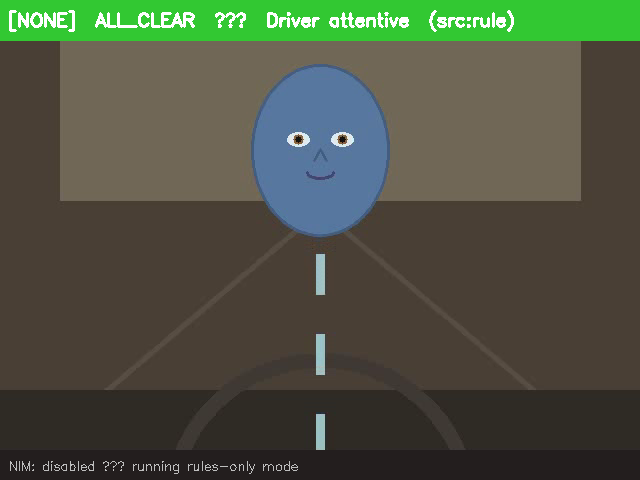

────────────────────────────────────────────────────

    75    23.4ms     0.0ms  []                          [NONE] ALL_CLEAR
    78    21.6ms     0.0ms  []                          [NONE] ALL_CLEAR
    81    13.2ms     0.0ms  []                          [NONE] ALL_CLEAR
    84    22.8ms     0.0ms  []                          [NONE] ALL_CLEAR
    87    32.5ms     0.0ms  []                          [NONE] ALL_CLEAR
    90    19.3ms    21.5ms  ['stop sign']               [NONE] ALL_CLEAR
    93    25.3ms     0.0ms  []                          [NONE] ALL_CLEAR
    96    24.0ms     0.0ms  []                          [NONE] ALL_CLEAR

── Frame 96 annotated ──────────────────────────


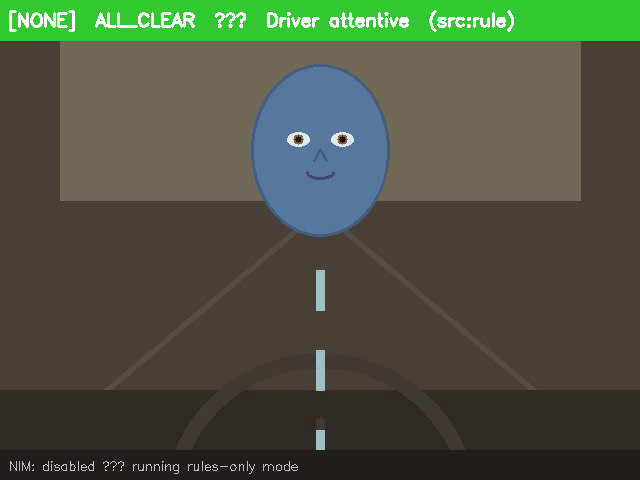

────────────────────────────────────────────────────

    99    32.7ms     0.0ms  []                          [NONE] ALL_CLEAR
   102    15.2ms     0.0ms  []                          [NONE] ALL_CLEAR
   105    19.5ms     0.0ms  []                          [NONE] ALL_CLEAR
   108    13.1ms     0.0ms  []                          [NONE] ALL_CLEAR
   111    14.4ms    16.6ms  ['stop sign']               [NONE] ALL_CLEAR
   114    22.1ms     0.0ms  []                          [NONE] ALL_CLEAR
   117    13.6ms     0.0ms  []                          [NONE] ALL_CLEAR
   120    13.3ms     0.0ms  []                          [NONE] ALL_CLEAR

── Frame 120 annotated ──────────────────────────


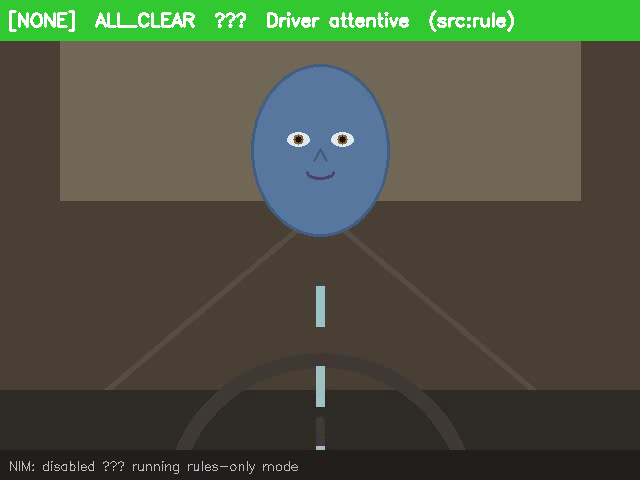

────────────────────────────────────────────────────

   123    14.6ms     0.0ms  []                          [NONE] ALL_CLEAR
   126    15.4ms     0.0ms  []                          [NONE] ALL_CLEAR
   129    15.1ms    19.0ms  ['stop sign']               [NONE] ALL_CLEAR
   132    17.8ms     0.0ms  []                          [NONE] ALL_CLEAR
   135    14.5ms     0.0ms  []                          [NONE] ALL_CLEAR
   138    12.5ms     0.0ms  []                          [NONE] ALL_CLEAR
   141    12.3ms     0.0ms  []                          [NONE] ALL_CLEAR
   144    14.8ms     0.0ms  []                          [NONE] ALL_CLEAR

── Frame 144 annotated ──────────────────────────


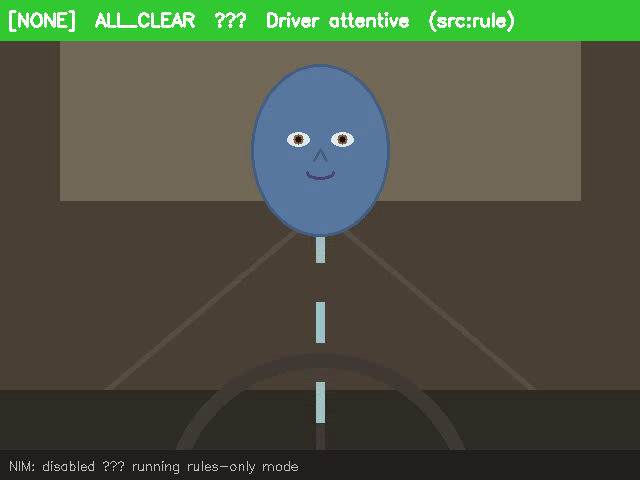

────────────────────────────────────────────────────

   147    41.1ms     0.0ms  []                          [NONE] ALL_CLEAR
   150    16.7ms    17.5ms  ['stop sign']               [NONE] ALL_CLEAR
   153    23.4ms     0.0ms  []                          [NONE] ALL_CLEAR
   156    33.8ms     0.0ms  []                          [NONE] ALL_CLEAR
   159    14.0ms     0.0ms  []                          [NONE] ALL_CLEAR
   162    24.8ms     0.0ms  []                          [NONE] ALL_CLEAR
   165    25.3ms     0.0ms  []                          [NONE] ALL_CLEAR
   168    26.0ms     0.0ms  []                          [NONE] ALL_CLEAR

── Frame 168 annotated ──────────────────────────


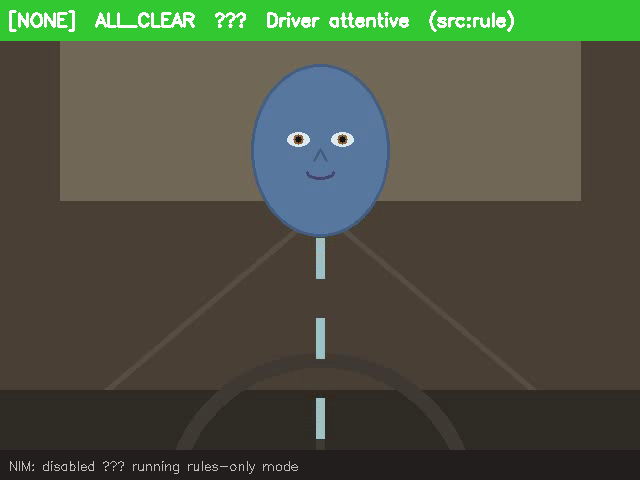

────────────────────────────────────────────────────

   171    40.8ms    19.2ms  ['stop sign']               [NONE] ALL_CLEAR
   174    45.1ms     0.0ms  []                          [NONE] ALL_CLEAR
   177    25.7ms     0.0ms  []                          [NONE] ALL_CLEAR
   180    45.0ms     0.0ms  []                          [MEDIUM] LOOKING_AWAY
   183    14.7ms     0.0ms  []                          [MEDIUM] LOOKING_AWAY
   186    37.8ms     0.0ms  []                          [MEDIUM] LOOKING_AWAY
   189    25.7ms     0.0ms  []                          [MEDIUM] LOOKING_AWAY
   192    14.8ms     0.0ms  []                          [MEDIUM] LOOKING_AWAY

── Frame 192 annotated ──────────────────────────


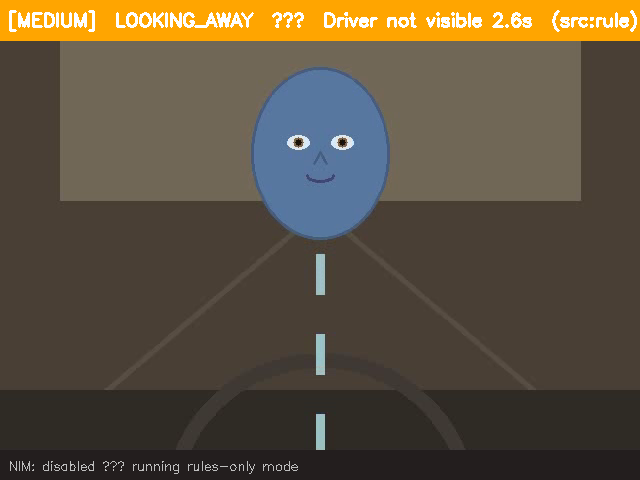

────────────────────────────────────────────────────

   195    34.2ms     0.0ms  []                          [MEDIUM] LOOKING_AWAY
   198    27.8ms     0.0ms  []                          [MEDIUM] LOOKING_AWAY
   201    21.4ms     0.0ms  []                          [MEDIUM] LOOKING_AWAY
   204    19.3ms     0.0ms  []                          [MEDIUM] LOOKING_AWAY
   207    16.4ms     0.0ms  []                          [MEDIUM] LOOKING_AWAY
   210    13.5ms     0.0ms  []                          [MEDIUM] LOOKING_AWAY
   213    19.3ms     0.0ms  []                          [MEDIUM] LOOKING_AWAY
   216    17.5ms     0.0ms  []                          [MEDIUM] LOOKING_AWAY

── Frame 216 annotated ──────────────────────────


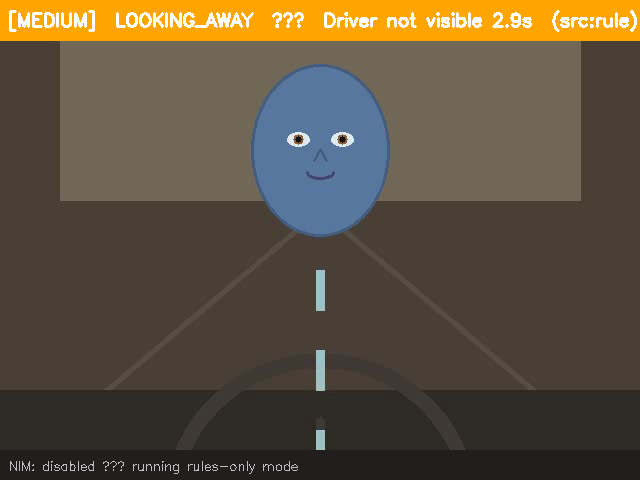

────────────────────────────────────────────────────

   219    16.2ms     0.0ms  []                          [MEDIUM] LOOKING_AWAY
   222    18.8ms     0.0ms  []                          [MEDIUM] LOOKING_AWAY
   225    23.3ms     0.0ms  []                          [MEDIUM] LOOKING_AWAY
   228    25.8ms     0.0ms  []                          [MEDIUM] LOOKING_AWAY
   231    16.3ms    18.4ms  ['stop sign']               [MEDIUM] LOOKING_AWAY
   234    12.6ms     0.0ms  []                          [MEDIUM] LOOKING_AWAY
   237    15.0ms     0.0ms  []                          [MEDIUM] LOOKING_AWAY
   240    22.0ms     0.0ms  []                          [MEDIUM] LOOKING_AWAY

── Frame 240 annotated ──────────────────────────


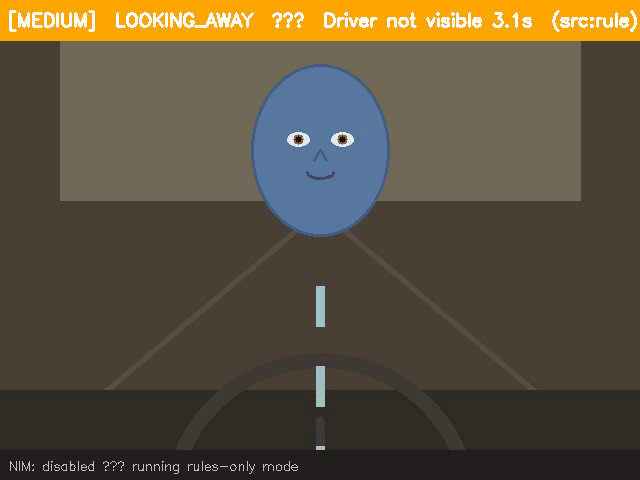

────────────────────────────────────────────────────


Done — 80 frames processed from 900 total


In [ ]:
import os, time

if not os.path.exists(VIDEO_PATH):
    raise FileNotFoundError(
        f"Video not found: {VIDEO_PATH}\n"
        "Run Cell 2 first to generate it!"
    )

cap = cv2.VideoCapture(VIDEO_PATH)
assert cap.isOpened(), f"Cannot open {VIDEO_PATH}"

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps_src      = cap.get(cv2.CAP_PROP_FPS)
print(f"Video : {total_frames} frames @ {fps_src:.1f} FPS")
print(f"Config: YOLO every {INFER_EVERY_N} frames, max {MAX_FRAMES} inferences")
print()
print(f"{'Frame':>6}  {'YOLO':>8}  {'NIM':>8}  "
      f"{'Detections':<26}  {'Alert'}")
print("─" * 76)

frame_idx   = 0
infer_count = 0
last_nim    = None
alert_log   = []
SHOW_EVERY  = 8     # display annotated frame every N inferences

while infer_count < MAX_FRAMES:
    ret, frame = cap.read()
    if not ret:
        print("End of video.")
        break
    frame_idx += 1
    if frame_idx % INFER_EVERY_N != 0:
        continue

    # ── YOLO ──────────────────────────────────────────────────
    t0   = time.perf_counter()
    dets = detector.detect(frame)
    yolo_ms = (time.perf_counter() - t0) * 1000

    # ── ROI extraction ─────────────────────────────────────────
    rois = extractor.extract(frame, dets)

    # ── NIM call (skipped if disabled) ─────────────────────────
    nim_ms = 0.0
    if nim_client and rois:
        t1      = time.perf_counter()
        last_nim = nim_client.reason(rois, dets)
        nim_ms  = (time.perf_counter() - t1) * 1000
        engine.update_nim(last_nim)

    # ── Decision ───────────────────────────────────────────────
    alert = engine.evaluate(dets)
    infer_count += 1

    # Log
    alert_log.append({
        "frame":   frame_idx,
        "yolo_ms": round(yolo_ms, 1),
        "nim_ms":  round(nim_ms,  1),
        "dets":    [d.label for d in dets[:4]],
        "alert":   alert.code,
        "level":   alert.level.name,
    })

    # Print row
    det_str = str([d.label for d in dets[:3]])[:26]
    print(f"{frame_idx:>6}  {yolo_ms:>6.1f}ms  {nim_ms:>6.1f}ms  "
          f"{det_str:<26}  [{alert.level.name}] {alert.code}")

    # Show annotated frame
    if infer_count % SHOW_EVERY == 0:
        annotated = draw_overlay(frame, dets, alert, last_nim)
        print(f"\n── Frame {frame_idx} annotated ──────────────────────────")
        cv2_imshow(annotated)
        print("─" * 52 + "\n")

cap.release()
print()
print(f"Done — {infer_count} frames processed from {total_frames} total")

In [ ]:
from collections import Counter

if not alert_log:
    print("No results yet — run Cell 7 first")
else:
    n         = len(alert_log)
    avg_yolo  = sum(r["yolo_ms"] for r in alert_log) / n
    avg_nim   = sum(r["nim_ms"]  for r in alert_log) / n

    level_counts = Counter(r["level"]  for r in alert_log)
    det_counts   = Counter(lb for r in alert_log for lb in r["dets"])

    print("=" * 54)
    print("  PIPELINE RESULTS SUMMARY")
    print("=" * 54)
    print(f"  Frames processed    : {n}")
    print(f"  Avg YOLO latency    : {avg_yolo:.1f} ms")
    print(f"  Avg NIM latency     : {avg_nim:.1f} ms"
          + ("  (0 = NIM disabled)" if avg_nim == 0 else ""))
    print()

    order = ["NONE","LOW","MEDIUM","HIGH","CRITICAL"]
    print("  Alert distribution:")
    for lvl in order:
        cnt = level_counts.get(lvl, 0)
        if cnt == 0:
            continue
        pct = cnt / n * 100
        bar = "█" * max(1, int(pct / 4))
        print(f"    {lvl:<10}  {bar:<24}  {cnt:3d}  ({pct:.0f}%)")

    print()
    print("  Top detected objects:")
    for label, cnt in det_counts.most_common(8):
        print(f"    {label:<22}  {cnt:4d} frames")

    print()
    flagged = [r for r in alert_log if r["level"] in ("HIGH", "CRITICAL")]
    if flagged:
        print(f"  HIGH/CRITICAL alerts ({len(flagged)}):")
        for r in flagged[:10]:
            print(f"    Frame {r['frame']:4d} → [{r['level']}] {r['alert']}")
    else:
        print("  No HIGH/CRITICAL alerts — pipeline ran clean")
    print("=" * 54)


  PIPELINE RESULTS SUMMARY
  Frames processed    : 80
  Avg YOLO latency    : 49.3 ms
  Avg NIM latency     : 2.5 ms

  Alert distribution:
    NONE        ██████████████████         59  (74%)
    MEDIUM      ██████                     21  (26%)

  Top detected objects:
    stop sign                  8 frames

  No HIGH/CRITICAL alerts — pipeline ran clean
